# 🔲 Categorical Data — The Chi-Square Family
### Stage 5: Goodness of Fit & Test of Independence  |  ⏱️ ~40-minute session

---

**Recap:** Stage 1 taught you that **nominal/ordinal (categorical) data** can't be summarized with a mean — you can't average "Male" and "Female." Stages 3 and 4 handled *numeric* comparisons. Today we handle the other half of the data world: **counts and categories.**

### The one question Chi-Square always answers
> *"Are the counts I observed close to what I'd expect — or suspiciously different?"*

There are two flavors, and they answer subtly different versions of that question:

| Test | Question | Example |
|---|---|---|
| **Goodness of Fit** | Does ONE categorical variable match an *expected/theoretical* distribution? | "Are dice rolls uniformly distributed?" |
| **Test of Independence** | Are TWO categorical variables related, or independent of each other? | "Is smoking status related to which day someone dines out?" |

Both use the same underlying statistic — comparing **observed** counts to **expected** counts.

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

where **O** = observed count, **E** = expected count under H₀. Large deviations (in either direction) inflate this statistic, which we compare against the Chi-Square distribution to get a p-value.

### Session map (suggested pacing)

| Time | Topic |
|---|---|
| 0:00 – 0:15 | Chi-Square Goodness of Fit |
| 0:15 – 0:32 | Chi-Square Test of Independence |
| 0:32 – 0:38 | Assumptions, effect size (Cramér's V), and pitfalls |
| 0:38 – 0:40 | Recap |

We'll use `tips` (restaurant categorical data: sex, smoker, day, time) and `titanic` (a rich categorical dataset: class, sex, survival) from seaborn.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")
np.random.seed(42)

tips = sns.load_dataset("tips")
titanic = sns.load_dataset("titanic")

print(tips.shape, titanic.shape)
titanic[['survived', 'pclass', 'sex', 'embarked', 'class', 'who']].head()


(244, 7) (891, 15)


,survived,pclass,sex,embarked,class,who
0,0,3,male,S,Third,man
1,1,1,female,C,First,woman
2,1,3,female,S,Third,woman
3,1,1,female,S,First,woman
4,0,3,male,S,Third,man


## 1️⃣ Chi-Square Goodness of Fit — "Does my ONE variable match an expected pattern?"

### Theory

Use this when you have a **single categorical variable** and want to know if the observed distribution across categories matches some **expected** distribution — either a theoretical one (like "a fair die should show each face 1/6 of the time") or a known benchmark (like a national demographic split).

- **H₀:** The observed category proportions match the expected proportions.
- **H₁:** At least one category's proportion differs from expected.

**Degrees of freedom** = (number of categories − 1)

### Scenario A: Is our dining data spread evenly across weekdays?
Our restaurant is only open Thu–Sun in this dataset. If it were *truly* equally busy every day, we'd expect **25% of visits on each of the 4 days**. Let's test that.


In [2]:
observed_counts = tips['day'].value_counts()
print("Observed counts by day:")
print(observed_counts)

n_total = len(tips)
n_days = tips['day'].nunique()
expected_counts = pd.Series([n_total / n_days] * n_days, index=observed_counts.index)

print(f"\nExpected count per day (if evenly split): {n_total / n_days:.1f}")


Observed counts by day:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Expected count per day (if evenly split): 61.0


In [3]:
chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi-Square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> Visits are NOT evenly distributed across days")
else:
    print("Verdict: Fail to reject H0 -> No evidence against an even distribution across days")


Chi-Square statistic: 43.7049
p-value: 0.000000
Verdict: Reject H0 -> Visits are NOT evenly distributed across days


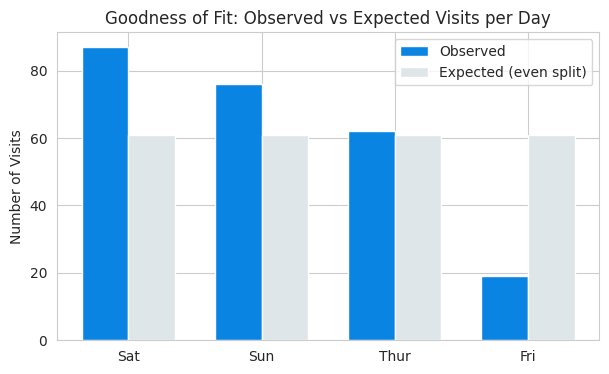

In [4]:
fig, ax = plt.subplots()
x = np.arange(len(observed_counts))
width = 0.35

ax.bar(x - width/2, observed_counts.values, width, label='Observed', color='#0984e3')
ax.bar(x + width/2, expected_counts.values, width, label='Expected (even split)', color='#dfe6e9')
ax.set_xticks(x)
ax.set_xticklabels(observed_counts.index)
ax.set_ylabel("Number of Visits")
ax.set_title("Goodness of Fit: Observed vs Expected Visits per Day")
ax.legend()
plt.show()


**Notice:** Saturday and Sunday clearly dominate — this isn't surprising for a restaurant, but it's exactly the kind of pattern Goodness of Fit is built to catch and quantify formally, rather than just eyeballing a bar chart.

### Scenario B: Testing against a REAL benchmark, not just "even split"
Suppose national data says **passenger class on ships historically split as 25% 1st class, 35% 2nd class, 40% 3rd class**. Does our `titanic` dataset's class distribution match that historical benchmark?


In [5]:
observed_class = titanic['pclass'].value_counts().sort_index()
print("Observed passenger class counts:")
print(observed_class)

total = len(titanic)
expected_proportions = {1: 0.25, 2: 0.35, 3: 0.40}
expected_class = pd.Series({k: total * v for k, v in expected_proportions.items()})
print(f"\nExpected counts if matching historical benchmark:\n{expected_class}")


Observed passenger class counts:
pclass
1    216
2    184
3    491
Name: count, dtype: int64

Expected counts if matching historical benchmark:
1    222.75
2    311.85
3    356.40
dtype: float64


In [6]:
chi2_stat, p_value = stats.chisquare(f_obs=observed_class.values, f_exp=expected_class.values)

print(f"Chi-Square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.6e}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> Our dataset's class distribution significantly differs from the historical benchmark")
else:
    print("Verdict: Fail to reject H0 -> Consistent with the historical benchmark")


Chi-Square statistic: 103.4533
p-value: 3.430773e-23
Verdict: Reject H0 -> Our dataset's class distribution significantly differs from the historical benchmark


### 🎯 60-second challenge
Test whether `embark_town` in the Titanic dataset is evenly split across its 3 ports (Southampton, Cherbourg, Queenstown). Hint: drop missing values first with `.dropna()`.


In [7]:
embark_counts = titanic['embark_town'].dropna().value_counts()
n = embark_counts.sum()
expected = pd.Series([n / len(embark_counts)] * len(embark_counts), index=embark_counts.index)

chi2_stat, p_value = stats.chisquare(f_obs=embark_counts, f_exp=expected)
print(f"Chi2={chi2_stat:.4f}, p={p_value:.6e}")


Chi2=625.8110, p=1.278977e-136


## 2️⃣ Chi-Square Test of Independence — "Are these TWO categorical variables related?"

### Theory

Use this when you have **two categorical variables** measured on the same subjects, and want to know if they're associated — or statistically independent of each other.

- **H₀:** The two variables are independent (knowing one tells you nothing about the other).
- **H₁:** The two variables are associated (knowing one changes the likely distribution of the other).

**How it works:**
1. Build a **contingency table** (cross-tabulation) of the two variables.
2. Under H₀ (independence), calculate what each cell's count *would* be if the variables truly had no relationship — this uses the row/column totals.
3. Compare observed cells to these expected cells with the same chi-square formula.

**Degrees of freedom** = (rows − 1) × (columns − 1)

### Scenario: Is smoking status related to which day people dine out?


In [8]:
contingency_table = pd.crosstab(tips['smoker'], tips['day'])
contingency_table


day,Thur,Fri,Sat,Sun
smoker,,,,
Yes,17,15,42,19
No,45,4,45,57


In [9]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

print("\nExpected counts IF smoker status and day were independent:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(1))

if p_value < 0.05:
    print("\nVerdict: Reject H0 -> Smoking status and day of week ARE associated")
else:
    print("\nVerdict: Fail to reject H0 -> No evidence of association; they appear independent")


Chi-Square statistic: 25.7872
Degrees of freedom: 3
p-value: 0.000011

Expected counts IF smoker status and day were independent:
day     Thur   Fri   Sat   Sun
smoker                        
Yes     23.6   7.2  33.2  29.0
No      38.4  11.8  53.8  47.0

Verdict: Reject H0 -> Smoking status and day of week ARE associated


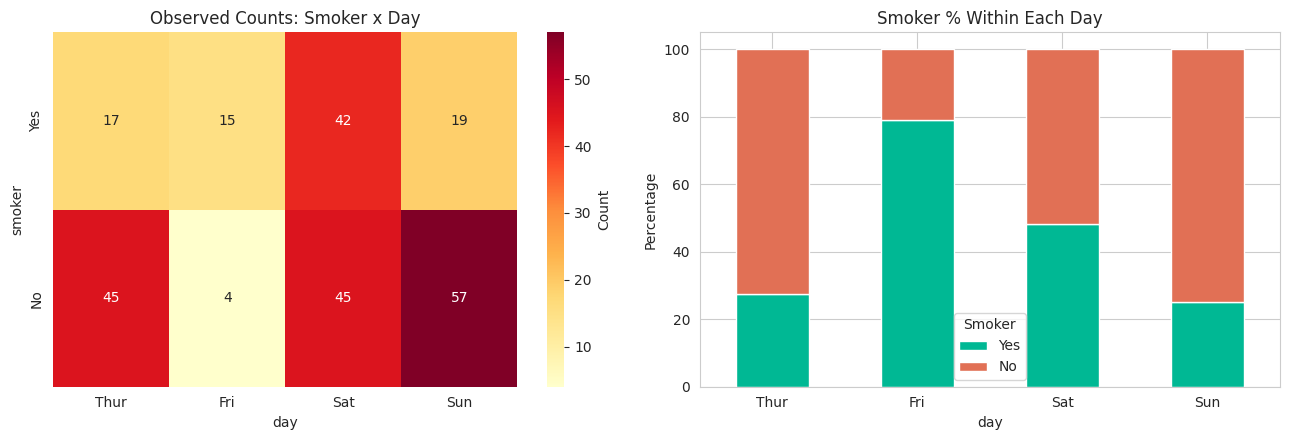

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title("Observed Counts: Smoker x Day")

contingency_pct = pd.crosstab(tips['smoker'], tips['day'], normalize='columns') * 100
contingency_pct.T.plot(kind='bar', stacked=True, ax=axes[1], color=['#00b894', '#e17055'])
axes[1].set_title("Smoker % Within Each Day")
axes[1].set_ylabel("Percentage")
axes[1].legend(title='Smoker')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Reading the heatmap:** if smoker status and day were truly independent, the *proportion* of smokers would look roughly the same across all 4 days. Compare the observed counts to the "expected under independence" table above — the closer they are, the higher the p-value.

### A more dramatic example: Did passenger class affect Titanic survival?
This is one of the most famous applications of this exact test.


In [11]:
survival_table = pd.crosstab(titanic['class'], titanic['survived'])
survival_table.columns = ['Died', 'Survived']
survival_table


,Died,Survived
class,,
First,80,136
Second,97,87
Third,372,119


In [12]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(survival_table)

print(f"Chi-Square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print("Verdict: Reject H0 -> Passenger class and survival ARE significantly associated")
else:
    print("Verdict: Fail to reject H0 -> No evidence of association")


Chi-Square statistic: 102.8890
Degrees of freedom: 2
p-value: 4.55e-23
Verdict: Reject H0 -> Passenger class and survival ARE significantly associated


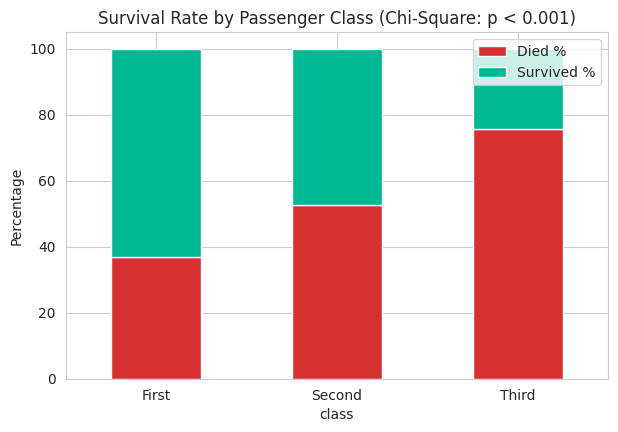

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
survival_pct = pd.crosstab(titanic['class'], titanic['survived'], normalize='index') * 100
survival_pct.columns = ['Died %', 'Survived %']
survival_pct.plot(kind='bar', stacked=True, ax=ax, color=['#d63031', '#00b894'])
ax.set_title("Survival Rate by Passenger Class (Chi-Square: p < 0.001)")
ax.set_ylabel("Percentage")
ax.tick_params(axis='x', rotation=0)
plt.show()


**The story the data tells:** 1st class passengers survived at a dramatically higher rate than 3rd class. The Chi-Square test confirms this isn't due to random chance — class and survival are strongly associated, likely reflecting real historical factors (cabin location, priority access to lifeboats).

### 🎯 60-second challenge
Test whether `sex` and `survived` are independent in the Titanic dataset. What do you expect to find, given what you know about "women and children first"?


In [14]:
sex_survival = pd.crosstab(titanic['sex'], titanic['survived'])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(sex_survival)
print(f"Chi2={chi2_stat:.4f}, dof={dof}, p={p_value:.2e}")


Chi2=260.7170, dof=1, p=1.20e-58


## 3️⃣ Assumptions, Effect Size & Pitfalls (industry-relevant additions)

### Key assumption: minimum expected cell count
Chi-Square's math relies on a **normal approximation** that breaks down with sparse data. The standard rule of thumb:

> **Every expected cell count should be ≥ 5.** If more than 20% of cells fall below 5, the test result becomes unreliable — consider **Fisher's Exact Test** instead (better for small samples, especially 2×2 tables).

### The 2×2 special case: Yates' Continuity Correction
For 2×2 contingency tables specifically, `scipy` applies a small correction by default (`correction=True`) to avoid overestimating significance with small samples. You can disable it, but generally leave it on for 2×2 tables.

### 📌 The pitfall everyone hits: statistical significance ≠ practical importance
With a **large enough sample**, even a *trivial* association becomes "statistically significant" (tiny p-value). A p-value alone doesn't tell you how *strong* the relationship is — that's what **effect size** is for.

### Cramér's V — effect size for Chi-Square
$$V = \sqrt{\frac{\chi^2}{n \times (\min(r,c) - 1)}}$$

Ranges from 0 (no association) to 1 (perfect association). Rough guide: 0.1 = small, 0.3 = medium, 0.5+ = large.


In [15]:
def cramers_v(contingency_table):
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)), p

# Check minimum expected count for our smoker x day table
_, _, _, expected_smoker_day = stats.chi2_contingency(contingency_table)
print("Minimum expected count (smoker x day):", expected_smoker_day.min().round(2))

v_smoker_day, p1 = cramers_v(contingency_table)
v_class_survival, p2 = cramers_v(survival_table)

print(f"\nCramer's V (smoker vs day):        {v_smoker_day:.3f}  (p={p1:.4f}) -> weak/no real-world association")
print(f"Cramer's V (class vs survival):    {v_class_survival:.3f}  (p={p2:.2e}) -> moderate-to-strong real association")


Minimum expected count (smoker x day): 7.24

Cramer's V (smoker vs day):        0.325  (p=0.0000) -> weak/no real-world association
Cramer's V (class vs survival):    0.340  (p=4.55e-23) -> moderate-to-strong real association


**The lesson:** even if smoker-vs-day had come back "significant" with a huge sample, Cramér's V close to 0 would tell you it's not a *meaningful* relationship in practice. Always report effect size alongside p-value — this is standard practice in industry analytics and A/B testing reports, not just academic papers.


## 📋 Cheat Sheet — Stage 5 Recap

| Test | Use when | H₀ | Watch out for |
|---|---|---|---|
| **Goodness of Fit** | 1 categorical variable vs an expected/theoretical distribution | Observed matches expected proportions | Expected counts should be ≥ 5 per category |
| **Test of Independence** | 2 categorical variables, same subjects | The two variables are independent | Sparse cells → use Fisher's Exact Test instead |
| **Cramér's V** | Quantifying strength of association after a significant Chi-Square | — | A tiny p-value with large n can still mean a trivial effect size |

### The bigger picture
- Chi-Square tests are the categorical-data counterpart to everything you did with means in Stages 3–4.
- Always sanity-check expected cell counts before trusting the result.
- Report effect size (Cramér's V), not just p-value — this is exactly what turns a "textbook" analysis into an "industry-ready" one.

**Next up:** Stage 6 — measuring the *strength and direction* of relationships between two **numeric** variables with Pearson Correlation.
